# Comprehensive Analysis of All Network Architectures

This notebook performs comprehensive analysis comparing **all** architectures analyzed in the two_module notebooks:

1. **Task Regimes**: same, near, far (task similarity conditions)
2. **Architecture Types**: Non-modular (baseline) vs Modular (two-module)
3. **Communication Regimes**: none, low, high (inter-module communication levels, modular only)
4. **Embedding/Initialization Regimes**: rich_50, lazy_50, gamma_e_1_50 (learning dynamics)

## Configurations Analyzed

### Non-Modular Configurations (Baseline)
- `rich_50` - Rich embedding (γ=1e-3)
- `lazy_50` - Lazy embedding (γ=2)
- `gamma_e_1_50` - Intermediate embedding (γ=0.1)

### Modular Configurations (Two-Module)
- **Rich embedding** (γ=1e-3): `two_module_rich_50_{none,low,high}`
- **Lazy embedding** (γ=2): `two_module_lazy_50_{none,low,high}`
- **Intermediate embedding** (γ=0.1): `two_module_gamma_e_1_50_{none,low,high}`

**Total**: 12 configurations (3 non-modular + 9 modular)

**Primary Focus**: Comprehensive comparison of task switching effects, learning dynamics, module activations, and representational geometry across all architectures, enabling direct comparison between non-modular and modular networks.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Setup path
SCRIPT_DIR = Path(__file__).parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = SCRIPT_DIR.parent  # transfer-interference directory
sys.path.insert(0, str(PROJECT_ROOT))

# Imports from project
from src.analysis import ann
from src.utils import figure_settings, figure_utils
from src.utils.figure_settings import schedule_colours, cm_conv, med_fontsize

# Setup figure output
figure_path = PROJECT_ROOT / "figures" / "compare_all_architectures"
os.makedirs(figure_path, exist_ok=True)

# Set style
plt.style.use("default")
sns.set_palette("husl")
print("✓ Imports completed")

✓ Imports completed


## 1. Setup and Data Loading

Load data from all configurations: 3 non-modular + 9 modular (3 embedding regimes × 3 communication levels).

In [2]:
# Define all configurations to compare
# Non-modular configs (baseline for comparison)
non_modular_configs = ['rich_50', 'lazy_50', 'gamma_e_1_50']

# Modular configs (to compare with non-modular)
modular_configs = [
    'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high',
    'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high',
    'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high'
]

# Combined for loading - order: non-modular first, then modular grouped by gamma
all_configs = non_modular_configs + modular_configs

# Color scheme for architecture types
arch_colors = {
    'non_modular': '#2E7D32',  # green for non-modular
    'modular_none': '#808080',  # gray for modular none
    'modular_low': '#56B4E9',   # blue for modular low
    'modular_high': '#D9544D'   # red for modular high
}

# Load all simulation data
ann_data = {}
for config in all_configs:
    config_path = PROJECT_ROOT / 'data' / 'simulations' / config
    if config_path.exists():
        ann_data[config] = ann.load_ann_data(str(config_path))
        print(f"✓ Loaded {config}: {len(ann_data[config]['same'])} participants")
    else:
        print(f"⚠ Warning: {config} data not found, skipping...")
        ann_data[config] = {'same': [], 'near': [], 'far': []}

print(f"\nLoaded data for {len([c for c in all_configs if c in ann_data])} configurations")

✓ Loaded rich_50: 103 participants
✓ Loaded lazy_50: 103 participants
✓ Loaded gamma_e_1_50: 103 participants
✓ Loaded two_module_rich_50_none: 103 participants
✓ Loaded two_module_rich_50_low: 103 participants
✓ Loaded two_module_rich_50_high: 103 participants
✓ Loaded two_module_lazy_50_none: 103 participants
✓ Loaded two_module_lazy_50_low: 103 participants
✓ Loaded two_module_lazy_50_high: 103 participants
✓ Loaded two_module_gamma_e_1_50_none: 103 participants
✓ Loaded two_module_gamma_e_1_50_low: 103 participants
✓ Loaded two_module_gamma_e_1_50_high: 103 participants

Loaded data for 12 configurations


In [3]:
# Helper functions to categorize configurations
def get_config_type(config_name):
    """Determine if config is non-modular or modular, and extract communication regime if modular."""
    non_modular_configs = ['rich_50', 'lazy_50', 'gamma_e_1_50']
    if config_name in non_modular_configs:
        return 'non_modular', None, config_name
    elif config_name.startswith('two_module_'):
        # Extract communication regime from config name
        if config_name.endswith('_none'):
            return 'modular', 'none', config_name
        elif config_name.endswith('_low'):
            return 'modular', 'low', config_name
        elif config_name.endswith('_high'):
            return 'modular', 'high', config_name
        else:
            return 'modular', 'unknown', config_name
    else:
        return 'unknown', None, config_name

def get_embedding_type(config_name):
    """Extract embedding type from config name."""
    if 'rich' in config_name:
        return 'rich'
    elif 'lazy' in config_name:
        return 'lazy'
    elif 'gamma_e_1' in config_name:
        return 'gamma_e_1'
    else:
        return 'unknown'


## 2. Task Switching Analysis

Analyze transfer costs and interference at task boundaries (A1→B, B→A2).

In [4]:
if 'transfer_combined' in locals() and len(transfer_combined) > 0:
    # Define task regimes
    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    
    # Create multi-panel figure: rows = task regimes, columns = metrics
    fig, axes = plt.subplots(len(task_regimes), 2, figsize=(12*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    # Create a combined label for x-axis (architecture type + comm regime)
    transfer_combined['arch_label'] = transfer_combined.apply(
        lambda row: row['arch_type'] if row['arch_type'] == 'non_modular' 
        else f"{row['arch_type']}_{row['comm_regime']}", axis=1
    )
    retest_combined['arch_label'] = retest_combined.apply(
        lambda row: row['arch_type'] if row['arch_type'] == 'non_modular' 
        else f"{row['arch_type']}_{row['comm_regime']}", axis=1
    )
    
    # Define order: non-modular first, then modular by comm regime
    arch_label_order = ['non_modular', 'modular_none', 'modular_low', 'modular_high']
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        # Transfer error difference (A1→B)
        ax1 = axes[task_idx, 0]
        transfer_task = transfer_combined[transfer_combined['condition'] == task_regime]
        if len(transfer_task) > 0:
            # Use hue to separate by embedding type
            sns.stripplot(data=transfer_task, x='arch_label', y='transfer_error_diff', 
                          ax=ax1, order=arch_label_order, hue='embedding',
                          alpha=0.5, size=2, jitter=True, zorder=1, dodge=True)
            sns.pointplot(data=transfer_task, x='arch_label', y='transfer_error_diff',
                          ax=ax1, order=arch_label_order, color='black', markersize=3, zorder=2)
        ax1.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax1.set_xlabel('Architecture Type')
        if task_idx == 0:
            ax1.set_title('Transfer Cost (A1→B)')
        if task_idx == 0:
            ax1.set_ylabel('Transfer Error\nDifference')
        else:
            ax1.set_ylabel(f'{task_label}\nTransfer Error')
        ax1.tick_params(axis='x', rotation=45)
        figure_utils._style_axes(ax1)
        
        # Retest error difference (A1→A2)
        ax2 = axes[task_idx, 1]
        retest_task = retest_combined[retest_combined['condition'] == task_regime]
        if len(retest_task) > 0:
            sns.stripplot(data=retest_task, x='arch_label', y='retest_error_diff',
                          ax=ax2, order=arch_label_order, hue='embedding',
                          alpha=0.5, size=2, jitter=True, zorder=1, dodge=True)
            sns.pointplot(data=retest_task, x='arch_label', y='retest_error_diff',
                          ax=ax2, order=arch_label_order, color='black', markersize=3, zorder=2)
        ax2.axhline(0, color='gray', linestyle='--', linewidth=0.5)
        ax2.set_xlabel('Architecture Type')
        if task_idx == 0:
            ax2.set_title('Interference (A1→A2)')
        if task_idx == 0:
            ax2.set_ylabel('Retest Error\nDifference')
        else:
            ax2.set_ylabel(f'{task_label}\nRetest Error')
        ax2.tick_params(axis='x', rotation=45)
        figure_utils._style_axes(ax2)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'task_switching_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No data available for visualization")


No data available for visualization


In [5]:
# Visualize transfer and retest metrics

In [6]:
def extract_learning_curves(ann_data_dict, phase_idx=0, metric='accuracy', feature_idx=1):
    """Extract learning curves for a specific phase, preserving config information."""
    curves = {}
    
    # Structure: curves[config_name][task_regime] = list of curves
    for config_name, data in ann_data_dict.items():
        if len(data.get('same', [])) == 0:
            continue
        curves[config_name] = {}
        for schedule_name, schedule_data in data.items():
            if len(schedule_data) == 0:
                continue
            curves[config_name][schedule_name] = []
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                if metric == 'accuracy':
                    # Extract accuracy for specific feature (winter: feature_idx=1)
                    curve = subj_data['accuracy'][phase_idx, feature_idx::2].copy()
                elif metric == 'loss':
                    curve = subj_data['losses'][phase_idx, :].copy()
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                curves[config_name][schedule_name].append(curve)
    
    return curves
# Extract learning curves for each phase
phases = {'A1': 0, 'B': 1, 'A2': 2}
learning_curves = {}

for phase_name, phase_idx in phases.items():
    learning_curves[phase_name] = extract_learning_curves(ann_data, phase_idx, 'accuracy')
    learning_curves[phase_name]['loss'] = extract_learning_curves(ann_data, phase_idx, 'loss')

print("Learning curves extracted for all phases")
# Debug: Check what configs are in learning_curves
for phase_name in learning_curves.keys():
    configs = [k for k in learning_curves[phase_name].keys() if k != 'loss']
    print(f"{phase_name} phase - Configs found: {configs}")
    if len(configs) > 0:
        # Check one config's structure
        sample_config = configs[0]
        print(f"  Sample config '{sample_config}' has task regimes: {list(learning_curves[phase_name][sample_config].keys())}")

Learning curves extracted for all phases
A1 phase - Configs found: ['rich_50', 'lazy_50', 'gamma_e_1_50', 'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high', 'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high', 'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high']
  Sample config 'rich_50' has task regimes: ['same', 'near', 'far']
B phase - Configs found: ['rich_50', 'lazy_50', 'gamma_e_1_50', 'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high', 'two_module_lazy_50_none', 'two_module_lazy_50_low', 'two_module_lazy_50_high', 'two_module_gamma_e_1_50_none', 'two_module_gamma_e_1_50_low', 'two_module_gamma_e_1_50_high']
  Sample config 'rich_50' has task regimes: ['same', 'near', 'far']
A2 phase - Configs found: ['rich_50', 'lazy_50', 'gamma_e_1_50', 'two_module_rich_50_none', 'two_module_rich_50_low', 'two_module_rich_50_high', 'two_module_lazy_50_none', 'two_module_

In [7]:
def extract_module_activations(ann_data_dict):
    """Extract module activation statistics per phase, preserving config information."""
    activation_stats = {}
    
    for config_name, data in ann_data_dict.items():
        if len(data.get('same', [])) == 0:
            continue
        activation_stats[config_name] = {}
        
        for schedule_name, schedule_data in data.items():
            if len(schedule_data) == 0:
                continue
            activation_stats[config_name][schedule_name] = {
                'A1': {'mod_A': [], 'mod_B': []},
                'B': {'mod_A': [], 'mod_B': []},
                'A2': {'mod_A': [], 'mod_B': []}
            }
            
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                # Check if per-module hidden states exist
                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']  # (n_phase, n_trials, dim_hidden_per_module)
                    h_B = subj_data['hiddens_B']
                    
                    for phase_idx, phase_name in enumerate(['A1', 'B', 'A2']):
                        if h_A.shape[0] > phase_idx:
                            # Compute activation magnitude (L2 norm) for each trial
                            mod_A_activations = np.linalg.norm(h_A[phase_idx, :, :], axis=1)
                            mod_B_activations = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            
                            activation_stats[config_name][schedule_name][phase_name]['mod_A'].append(mod_A_activations)
                            activation_stats[config_name][schedule_name][phase_name]['mod_B'].append(mod_B_activations)
    
    return activation_stats


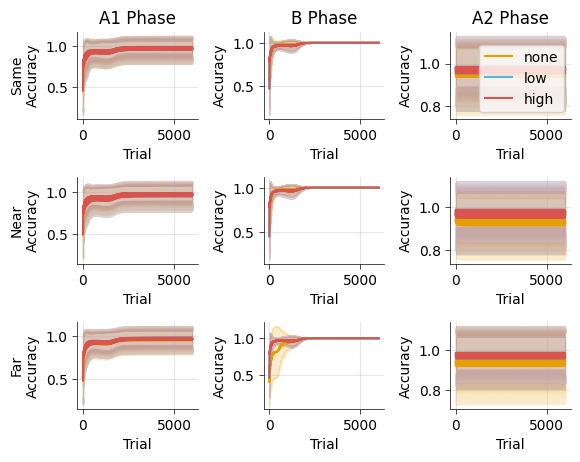

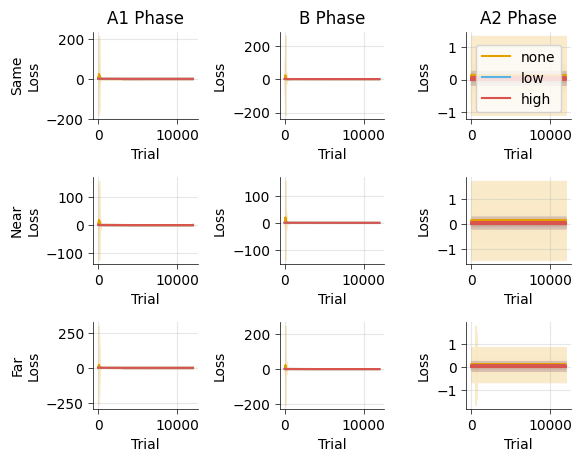

In [8]:
# Plot learning curves - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

# Accuracy curves: rows = task regimes, columns = phases
fig_acc, axes_acc = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
if len(task_regimes) == 1:
    axes_acc = axes_acc.reshape(1, -1)

for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
    for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
        ax = axes_acc[task_idx, phase_idx]
        # Group curves by comm_type (extracted from config names)
        comm_type_curves = {'none': [], 'low': [], 'high': []}
        comm_colors = {'none': '#E69F00', 'low': '#56B4E9', 'high': '#D9544D'}
        
        # Iterate through configs and group by comm_type
        # learning_curves[phase_name] contains accuracy data (config_name -> task_regime -> curves)
        for config_name, config_data in learning_curves[phase_name].items():
            if config_name == 'loss':  # Skip the 'loss' key
                continue
            if task_regime in config_data:
                # Extract comm_type from config name
                if config_name.endswith('_none'):
                    comm_type = 'none'
                elif config_name.endswith('_low'):
                    comm_type = 'low'
                elif config_name.endswith('_high'):
                    comm_type = 'high'
                else:
                    # Non-modular configs - assign to 'none' for visualization
                    # or skip if you want to show only modular configs
                    comm_type = 'none'  # Group non-modular with 'none' for now
                
                # Add curves for this comm_type
                comm_type_curves[comm_type].extend(config_data[task_regime])
        
        # Check if we have any data
        total_curves = sum(len(curves) for curves in comm_type_curves.values())
        if total_curves == 0 and task_idx == 0 and phase_idx == 0:
            # Debug: print what configs we found (only once)
            configs_found = [k for k in learning_curves[phase_name].keys() if k != 'loss']
            print(f"Debug: {phase_name} phase has configs: {configs_found}")
            if len(configs_found) > 0:
                sample_config = configs_found[0]
                print(f"  Sample '{sample_config}' has regimes: {list(learning_curves[phase_name][sample_config].keys())}")
        
        # Plot curves for each comm_type
        for comm_type in ['none', 'low', 'high']:
            curves = comm_type_curves[comm_type]
            if len(curves) > 0:
                        min_len = min(len(c) for c in curves)
                        curves_aligned = [c[:min_len] for c in curves]
                        curves_array = np.array(curves_aligned)
                        
                        mean_curve = np.mean(curves_array, axis=0)
                        std_curve = np.std(curves_array, axis=0)
                        x = np.arange(len(mean_curve))
                        
                        ax.plot(x, mean_curve, color=comm_colors[comm_type], 
                               label=comm_type, linewidth=1.5)
                        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                       color=comm_colors[comm_type], alpha=0.2)
        
        ax.set_xlabel('Trial')
        if task_idx == 0:
            ax.set_title(f'{phase_name} Phase')
        if phase_idx == 0:
            ax.set_ylabel(f'{task_label}\nAccuracy')
        else:
            ax.set_ylabel('Accuracy')
        if task_idx == 0 and phase_idx == len(phases) - 1:
            ax.legend()
        ax.grid(True, alpha=0.3)
        figure_utils._style_axes(ax)

plt.tight_layout()
plt.savefig(figure_path / 'learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Loss curves: rows = task regimes, columns = phases
fig_loss, axes_loss = plt.subplots(len(task_regimes), len(phases), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
if len(task_regimes) == 1:
    axes_loss = axes_loss.reshape(1, -1)

for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
    for phase_idx, (phase_name, phase_num) in enumerate(phases.items()):
        ax = axes_loss[task_idx, phase_idx]
        # Group curves by comm_type (extracted from config names)
        comm_type_curves = {'none': [], 'low': [], 'high': []}
        comm_colors = {'none': '#E69F00', 'low': '#56B4E9', 'high': '#D9544D'}
        
        # Iterate through configs and group by comm_type for loss data
        if 'loss' in learning_curves[phase_name]:
            for config_name, config_data in learning_curves[phase_name]['loss'].items():
                if task_regime in config_data:
                    # Extract comm_type from config name
                    if config_name.endswith('_none'):
                        comm_type = 'none'
                    elif config_name.endswith('_low'):
                        comm_type = 'low'
                    elif config_name.endswith('_high'):
                        comm_type = 'high'
                    else:
                        # Non-modular configs - assign to 'none' for visualization
                        comm_type = 'none'  # Group non-modular with 'none' for now
                    
                    # Add curves for this comm_type
                    comm_type_curves[comm_type].extend(config_data[task_regime])
        
        # Plot curves for each comm_type
        for comm_type in ['none', 'low', 'high']:
            curves = comm_type_curves[comm_type]
            if len(curves) > 0:
                        min_len = min(len(c) for c in curves)
                        curves_aligned = [c[:min_len] for c in curves]
                        curves_array = np.array(curves_aligned)
                        
                        mean_curve = np.mean(curves_array, axis=0)
                        std_curve = np.std(curves_array, axis=0)
                        x = np.arange(len(mean_curve))
                        
                        ax.plot(x, mean_curve, color=comm_colors[comm_type],
                               label=comm_type, linewidth=1.5)
                        ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                                       color=comm_colors[comm_type], alpha=0.2)
        
        ax.set_xlabel('Trial')
        if task_idx == 0:
            ax.set_title(f'{phase_name} Phase')
        if phase_idx == 0:
            ax.set_ylabel(f'{task_label}\nLoss')
        else:
            ax.set_ylabel('Loss')
        if task_idx == 0 and phase_idx == len(phases) - 1:
            ax.legend()
        ax.grid(True, alpha=0.3)
        figure_utils._style_axes(ax)

plt.tight_layout()
plt.savefig(figure_path / 'learning_curves_loss.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# Visualize module activations - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']
phases_list = ['A1', 'B', 'A2']

# Check if data exists
has_data = False
if activation_stats:
    for comm_type in activation_stats:
        for task_regime in task_regimes:
            if task_regime in activation_stats[comm_type]:
                if len(activation_stats[comm_type][task_regime]['A1']['mod_A']) > 0:
                    has_data = True
                    break
        if has_data:
            break

if has_data:
    fig, axes = plt.subplots(len(task_regimes), len(phases_list), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for phase_idx, phase_name in enumerate(phases_list):
            ax = axes[task_idx, phase_idx]
            
            # Collect data for grouped bar chart
            mod_A_means = []
            mod_A_stds = []
            mod_B_means = []
            mod_B_stds = []
            comm_types_present = []
            
            for comm_type in ['none', 'low', 'high']:
                if comm_type in activation_stats and task_regime in activation_stats[comm_type]:
                    if len(activation_stats[comm_type][task_regime][phase_name]['mod_A']) > 0:
                        all_A = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_A'])
                        all_B = np.concatenate(activation_stats[comm_type][task_regime][phase_name]['mod_B'])
                        
                        mod_A_means.append(np.mean(all_A))
                        mod_A_stds.append(np.std(all_A))
                        mod_B_means.append(np.mean(all_B))
                        mod_B_stds.append(np.std(all_B))
                        comm_types_present.append(comm_type)
            
            if len(comm_types_present) > 0:
                x = np.arange(len(comm_types_present))
                width = 0.35
                
                ax.bar(x - width/2, mod_A_means, width, yerr=mod_A_stds, 
                       label='Module A', color='#b08cca', alpha=0.7, capsize=5)
                ax.bar(x + width/2, mod_B_means, width, yerr=mod_B_stds,
                       label='Module B', color='#aad39b', alpha=0.7, capsize=5)
                
                ax.set_xticks(x)
                ax.set_xticklabels(comm_types_present)
                ax.set_ylabel('Activation Magnitude (L2 norm)')
                if task_idx == 0:
                    ax.set_title(f'{phase_name} Phase')
                if phase_idx == 0:
                    ax.set_ylabel(f'{task_label}\nActivation Magnitude')
                if task_idx == 0 and phase_idx == len(phases_list) - 1:
                    ax.legend()
                figure_utils._style_axes(ax)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'module_activations.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No module activation data available")

NameError: name 'activation_stats' is not defined

## 5. Representational Geometry Analysis

Compare principal angles and PCA visualizations across communication regimes.

In [ ]:
# Analyze cross-module activation (inactive module receiving communication)
def analyze_cross_module_activation(ann_data_dict):
    """Analyze how much inactive modules activate via communication."""
    cross_activation = {}
    
    for comm_type, data in ann_data_dict.items():
        cross_activation[comm_type] = {
            'A_active_B_receives': [],  # During A1/A2, how much does B activate?
            'B_active_A_receives': []   # During B, how much does A activate?
        }
        
        for schedule_name, schedule_data in data.items():
            for subj in range(len(schedule_data)):
                subj_data = schedule_data[subj]
                
                if 'hiddens_A' in subj_data and 'hiddens_B' in subj_data:
                    h_A = subj_data['hiddens_A']
                    h_B = subj_data['hiddens_B']
                    
                    # During A1/A2 (Module A active), measure Module B activation
                    for phase_idx in [0, 2]:  # A1 and A2
                        if h_B.shape[0] > phase_idx:
                            mod_B_acts = np.linalg.norm(h_B[phase_idx, :, :], axis=1)
                            cross_activation[comm_type]['A_active_B_receives'].extend(mod_B_acts)
                    
                    # During B (Module B active), measure Module A activation
                    if h_A.shape[0] > 1:
                        mod_A_acts = np.linalg.norm(h_A[1, :, :], axis=1)
                        cross_activation[comm_type]['B_active_A_receives'].extend(mod_A_acts)
    
    return cross_activation

cross_activation = analyze_cross_module_activation(ann_data)

# Visualize cross-module activation - split by task regime
task_regimes = ['same', 'near', 'far']
task_labels = ['Same', 'Near', 'Far']

# Check if data exists
has_data = False
if cross_activation:
    for comm_type in cross_activation:
        for task_regime in task_regimes:
            if task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['A_active_B_receives']) > 0:
                    has_data = True
                    break
        if has_data:
            break

if has_data:
    fig, axes = plt.subplots(len(task_regimes), 2, figsize=(10*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        # Module B activation when A is active
        ax1 = axes[task_idx, 0]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['A_active_B_receives']) > 0:
                    acts = cross_activation[comm_type][task_regime]['A_active_B_receives']
                    mean_act = np.mean(acts)
                    std_act = np.std(acts)
                    ax1.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                           yerr=std_act, capsize=5)
        ax1.set_ylabel('Module B Activation\n(when A is active)')
        if task_idx == 0:
            ax1.set_title('Cross-Module Communication: A→B')
        if task_idx == 0:
            ax1.set_ylabel('Module B Activation\n(when A is active)')
        else:
            ax1.set_ylabel(f'{task_label}\nModule B Activation')
        ax1.set_xticklabels(['none', 'low', 'high'])
        figure_utils._style_axes(ax1)
        
        # Module A activation when B is active
        ax2 = axes[task_idx, 1]
        for comm_type in ['none', 'low', 'high']:
            if comm_type in cross_activation and task_regime in cross_activation[comm_type]:
                if len(cross_activation[comm_type][task_regime]['B_active_A_receives']) > 0:
                    acts = cross_activation[comm_type][task_regime]['B_active_A_receives']
                    mean_act = np.mean(acts)
                    std_act = np.std(acts)
                    ax2.bar(comm_type, mean_act, color=comm_colors[comm_type], alpha=0.7,
                           yerr=std_act, capsize=5)
        ax2.set_ylabel('Module A Activation\n(when B is active)')
        if task_idx == 0:
            ax2.set_title('Cross-Module Communication: B→A')
        if task_idx == 0:
            ax2.set_ylabel('Module A Activation\n(when B is active)')
        else:
            ax2.set_ylabel(f'{task_label}\nModule A Activation')
        ax2.set_xticklabels(['none', 'low', 'high'])
        figure_utils._style_axes(ax2)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'cross_module_activation.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No cross-module activation data available")

No cross-module activation data available


Principal angles summary:
          within_task_A                                                        \
                  count       mean        std       min        25%        50%   
comm_type                                                                       
high              305.0  38.953194  18.017641  0.094873  25.649914  43.246090   
low               305.0  38.971012  18.016083  0.081565  25.558149  43.227539   
none              305.0  38.153896  17.616064  0.100871  27.202267  42.130772   

                                within_task_B             ...             \
                 75%        max         count       mean  ...        75%   
comm_type                                                 ...              
high       52.258842  73.640694         305.0  39.172005  ...  51.865433   
low        52.151031  73.610107         305.0  39.207676  ...  51.915459   
none       51.733665  71.842308         305.0  38.471516  ...  51.650715   

                     across_ta

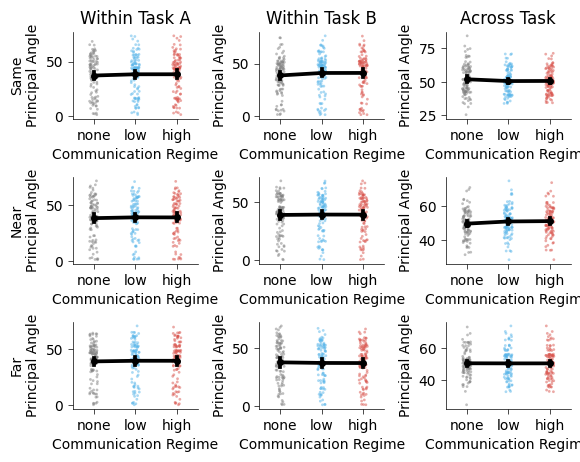

In [ ]:
# Compute principal angles for each condition
principal_angles = {}

for comm_type, data in ann_data.items():
    if len(data['same']) > 0:
        pa_df = ann.get_principal_angles(data)
        pa_df['comm_type'] = comm_type
        principal_angles[comm_type] = pa_df

# Combine principal angle data
if principal_angles:
    pa_combined = pd.concat(principal_angles.values(), ignore_index=True)
    
    print("Principal angles summary:")
    print(pa_combined.groupby('comm_type')[['within_task_A', 'within_task_B', 'across_task']].describe())
    
    # Visualize principal angles - split by task regime
    task_regimes = ['same', 'near', 'far']
    task_labels = ['Same', 'Near', 'Far']
    metrics = ['within_task_A', 'within_task_B', 'across_task']
    metric_labels = ['Within Task A', 'Within Task B', 'Across Task']
    
    fig, axes = plt.subplots(len(task_regimes), len(metrics), figsize=(15*cm_conv, 4*len(task_regimes)*cm_conv))
    if len(task_regimes) == 1:
        axes = axes.reshape(1, -1)
    
    for task_idx, (task_regime, task_label) in enumerate(zip(task_regimes, task_labels)):
        for metric_idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
            ax = axes[task_idx, metric_idx]
            pa_task = pa_combined[pa_combined['condition'] == task_regime]
            if len(pa_task) > 0:
                sns.stripplot(data=pa_task, x='comm_type', y=metric,
                             ax=ax, order=['none', 'low', 'high'],
                             palette=[comm_colors[c] for c in ['none', 'low', 'high']],
                             alpha=0.5, size=2, jitter=True, zorder=1)
                sns.pointplot(data=pa_task, x='comm_type', y=metric,
                             ax=ax, order=['none', 'low', 'high'],
                             color='black', markersize=3, zorder=2)
            ax.set_xlabel('Communication Regime')
            if task_idx == 0:
                ax.set_title(label)
            if metric_idx == 0:
                ax.set_ylabel(f'{task_label}\nPrincipal Angle')
            else:
                ax.set_ylabel('Principal Angle')
            figure_utils._style_axes(ax)
    
    plt.tight_layout()
    plt.savefig(figure_path / 'principal_angles.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No principal angle data available")

## 6. Statistical Comparisons

Perform statistical tests comparing communication regimes.

In [ ]:
def compute_effect_size(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    
    if pooled_std == 0:
        return 0.0
    
    d = (mean1 - mean2) / pooled_std
    return d

# Statistical comparisons
if 'transfer_combined' in locals() and len(transfer_combined) > 0:
    print("=" * 60)
    print("STATISTICAL COMPARISONS")
    print("=" * 60)
    
    # Transfer cost comparisons
    print("\n1. Transfer Cost (A1→B) Comparisons:")
    print("-" * 60)
    
    transfer_same = transfer_combined[transfer_combined['condition'] == 'same']
    
    for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
        g1 = transfer_same[transfer_same['comm_type'] == comparison[0]]['transfer_error_diff'].values
        g2 = transfer_same[transfer_same['comm_type'] == comparison[1]]['transfer_error_diff'].values
        
        if len(g1) > 0 and len(g2) > 0:
            t_stat, p_val = stats.ttest_ind(g1, g2)
            effect_size = compute_effect_size(g1, g2)
            
            print(f"{comparison[0]} vs {comparison[1]}:")
            print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
            print(f"  Effect size (Cohen's d): {effect_size:.3f}")
            print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
            print()
    
    # Retest/interference comparisons
    if 'retest_combined' in locals() and len(retest_combined) > 0:
        print("\n2. Retest/Interference (A1→A2) Comparisons:")
        print("-" * 60)
        
        retest_same = retest_combined[retest_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = retest_same[retest_same['comm_type'] == comparison[0]]['retest_error_diff'].values
            g2 = retest_same[retest_same['comm_type'] == comparison[1]]['retest_error_diff'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
    
    # Principal angle comparisons
    if 'pa_combined' in locals() and len(pa_combined) > 0:
        print("\n3. Principal Angle Comparisons (Across-Task):")
        print("-" * 60)
        
        pa_same = pa_combined[pa_combined['condition'] == 'same']
        
        for comparison in [('none', 'low'), ('none', 'high'), ('low', 'high')]:
            g1 = pa_same[pa_same['comm_type'] == comparison[0]]['across_task'].values
            g2 = pa_same[pa_same['comm_type'] == comparison[1]]['across_task'].values
            
            if len(g1) > 0 and len(g2) > 0:
                t_stat, p_val = stats.ttest_ind(g1, g2)
                effect_size = compute_effect_size(g1, g2)
                
                print(f"{comparison[0]} vs {comparison[1]}:")
                print(f"  t-statistic: {t_stat:.3f}, p-value: {p_val:.4f}")
                print(f"  Effect size (Cohen's d): {effect_size:.3f}")
                print(f"  Mean difference: {np.mean(g1) - np.mean(g2):.4f}")
                print()
else:
    print("No data available for statistical comparisons")

STATISTICAL COMPARISONS

1. Transfer Cost (A1→B) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: 0.373, p-value: 0.7096
  Effect size (Cohen's d): 0.052
  Mean difference: 0.0063

none vs high:
  t-statistic: 0.252, p-value: 0.8012
  Effect size (Cohen's d): 0.035
  Mean difference: 0.0043

low vs high:
  t-statistic: -0.123, p-value: 0.9026
  Effect size (Cohen's d): -0.017
  Mean difference: -0.0020


2. Retest/Interference (A1→A2) Comparisons:
------------------------------------------------------------
none vs low:
  t-statistic: 10.340, p-value: 0.0000
  Effect size (Cohen's d): 1.441
  Mean difference: 0.0000

none vs high:
  t-statistic: 14.405, p-value: 0.0000
  Effect size (Cohen's d): 2.007
  Mean difference: 0.0002

low vs high:
  t-statistic: 11.274, p-value: 0.0000
  Effect size (Cohen's d): 1.571
  Mean difference: 0.0001


3. Principal Angle Comparisons (Across-Task):
--------------------------------------------------

In [ ]:
# Create summary table
if 'transfer_combined' in locals() and 'retest_combined' in locals():
    summary_data = []
    
    for comm_type in ['none', 'low', 'high']:
        # Transfer metrics
        transfer_subset = transfer_combined[
            (transfer_combined['comm_type'] == comm_type) & 
            (transfer_combined['condition'] == 'same')
        ]
        
        # Retest metrics
        retest_subset = retest_combined[
            (retest_combined['comm_type'] == comm_type) &
            (retest_combined['condition'] == 'same')
        ]
        
        if len(transfer_subset) > 0 and len(retest_subset) > 0:
            summary_data.append({
                'Communication Regime': comm_type,
                'Transfer Cost (A1→B)': f"{np.mean(transfer_subset['transfer_error_diff']):.4f} ± {np.std(transfer_subset['transfer_error_diff']):.4f}",
                'Interference (A1→A2)': f"{np.mean(retest_subset['retest_error_diff']):.4f} ± {np.std(retest_subset['retest_error_diff']):.4f}",
                'Final A1 Accuracy': f"{np.mean(retest_subset['final_A1_acc']):.4f} ± {np.std(retest_subset['final_A1_acc']):.4f}",
                'Mean A2 Accuracy': f"{np.mean(retest_subset['mean_A2_acc']):.4f} ± {np.std(retest_subset['mean_A2_acc']):.4f}",
            })
    
    if summary_data:
        summary_df = pd.DataFrame(summary_data)
        print("=" * 80)
        print("SUMMARY TABLE")
        print("=" * 80)
        print(summary_df.to_string(index=False))
        print()
        
        # Key insights
        print("=" * 80)
        print("KEY INSIGHTS")
        print("=" * 80)
        print("\n1. Transfer Cost (A1→B):")
        print("   - Measures performance drop when switching from Task A to Task B")
        print("   - Lower (more negative) values indicate better transfer")
        print("   - Communication may help Module B leverage Module A's knowledge")
        
        print("\n2. Interference (A1→A2):")
        print("   - Measures performance change when returning to Task A after B training")
        print("   - Negative values indicate catastrophic forgetting")
        print("   - Communication may help preserve Module A representations during B training")
        
        print("\n3. Communication Effects:")
        print("   - None: Modules are completely isolated")
        print("   - Low: Minimal information flow (scale=0.05)")
        print("   - High: Strong information flow (scale=0.1)")
        
        print("\n4. Questions to Consider:")
        print("   - Does communication reduce transfer cost?")
        print("   - Does communication prevent catastrophic forgetting?")
        print("   - Are there trade-offs between transfer and interference?")
        print("   - How does communication strength affect these metrics?")
    else:
        print("No summary data available")
else:
    print("No data available for summary")

SUMMARY TABLE
Communication Regime Transfer Cost (A1→B) Interference (A1→A2) Final A1 Accuracy Mean A2 Accuracy
                none     -0.4966 ± 0.1238      0.0000 ± 0.0000   0.9999 ± 0.0001  0.9999 ± 0.0001
                 low     -0.5029 ± 0.1178     -0.0000 ± 0.0000   0.9999 ± 0.0001  0.9999 ± 0.0001
                high     -0.5009 ± 0.1188     -0.0002 ± 0.0001   0.9999 ± 0.0001  0.9998 ± 0.0001

KEY INSIGHTS

1. Transfer Cost (A1→B):
   - Measures performance drop when switching from Task A to Task B
   - Lower (more negative) values indicate better transfer
   - Communication may help Module B leverage Module A's knowledge

2. Interference (A1→A2):
   - Measures performance change when returning to Task A after B training
   - Negative values indicate catastrophic forgetting
   - Communication may help preserve Module A representations during B training

3. Communication Effects:
   - None: Modules are completely isolated
   - Low: Minimal information flow (scale=0.05)
   - Hi

## 7. Summary and Insights

Summary table of key metrics and interpretation of communication effects.